In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.12.13


In [2]:
# Importanto Bibliotecas

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pmdarima as pm
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import root_mean_squared_error
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [3]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Flavio Renan Sant Anna" --iversions

Author: Flavio Renan Sant Anna

matplotlib: 3.10.9
numpy     : 2.4.4
pandas    : 3.0.2
platform  : 1.0.8
plotly    : 6.7.0
pmdarima  : 2.1.1
seaborn   : 0.13.2
sklearn   : 1.8.0
yfinance  : 1.3.0



In [4]:
# Definimos Todas Variáveis
tickers = {
    'Bovespa': '^BVSP',        
    'Dolar': 'BRL=X',        
    'SP500': '^GSPC',        
    'Shanghai': '000001.SS', # Bolsa da China
    'Petroleo': 'BZ=F',      
    'Minerio': 'TIO=F',      
    'Ouro': 'GC=F'    
}

print("Baixando as variaveis ...")

Baixando as variaveis ...


In [5]:
#  Baixamos os dados
df = yf.download(list(tickers.values()), period='3y')['Close']
df.rename(columns={v: k for k, v in tickers.items()}, inplace=True)

[*********************100%***********************]  7 of 7 completed


In [6]:
# Tratamento de valores nulos devido a calendários de feriados diferentes
df.ffill(inplace=True)
df.dropna(inplace=True)

In [7]:
df.shape

(781, 7)

In [8]:
df.head()

Ticker,Shanghai,Dolar,Petroleo,Ouro,Minerio,Bovespa,SP500
Date,,,,,,,
2023-05-22,3296.469971,4.9968,75.989998,1974.800049,107.160004,110213.0,4192.629883
2023-05-23,3246.239990,4.9661,76.839996,1972.400024,106.540001,109929.0,4145.580078
2023-05-24,3204.750000,4.9712,78.360001,1962.800049,105.559998,108800.0,4115.240234
2023-05-25,3201.260010,4.9586,76.260002,1943.099976,105.599998,110054.0,4151.279785
2023-05-26,3212.500000,5.0352,76.949997,1944.099976,105.410004,110906.0,4205.450195


In [9]:
df.columns

Index(['Shanghai', 'Dolar', 'Petroleo', 'Ouro', 'Minerio', 'Bovespa', 'SP500'], dtype='str', name='Ticker')

Text(0.5, 0, '\nData')

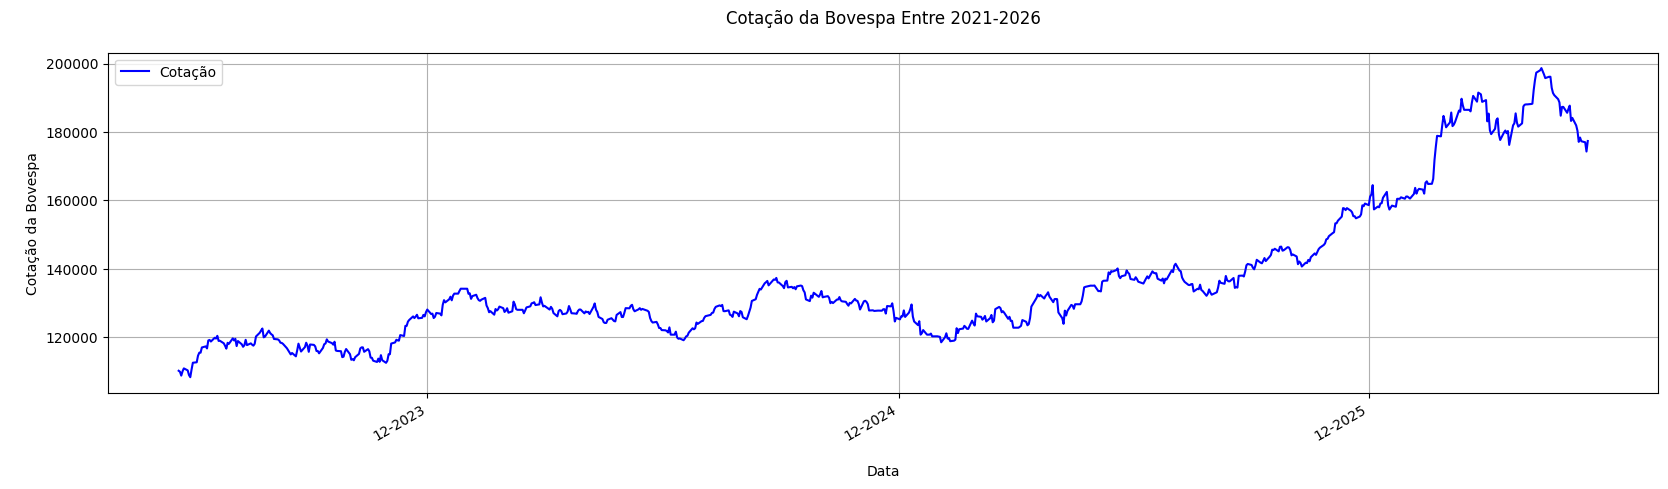

In [10]:
# Plot
plt.figure(figsize = (20,5))
plt.grid()
plt.plot(df.index, df['Bovespa'], color = 'blue')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval = 12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gcf().autofmt_xdate() 
plt.legend(['Cotação'], loc='best')
plt.title('Cotação da Bovespa Entre 2021-2026\n')
plt.ylabel('\nCotação da Bovespa')
plt.xlabel('\nData')

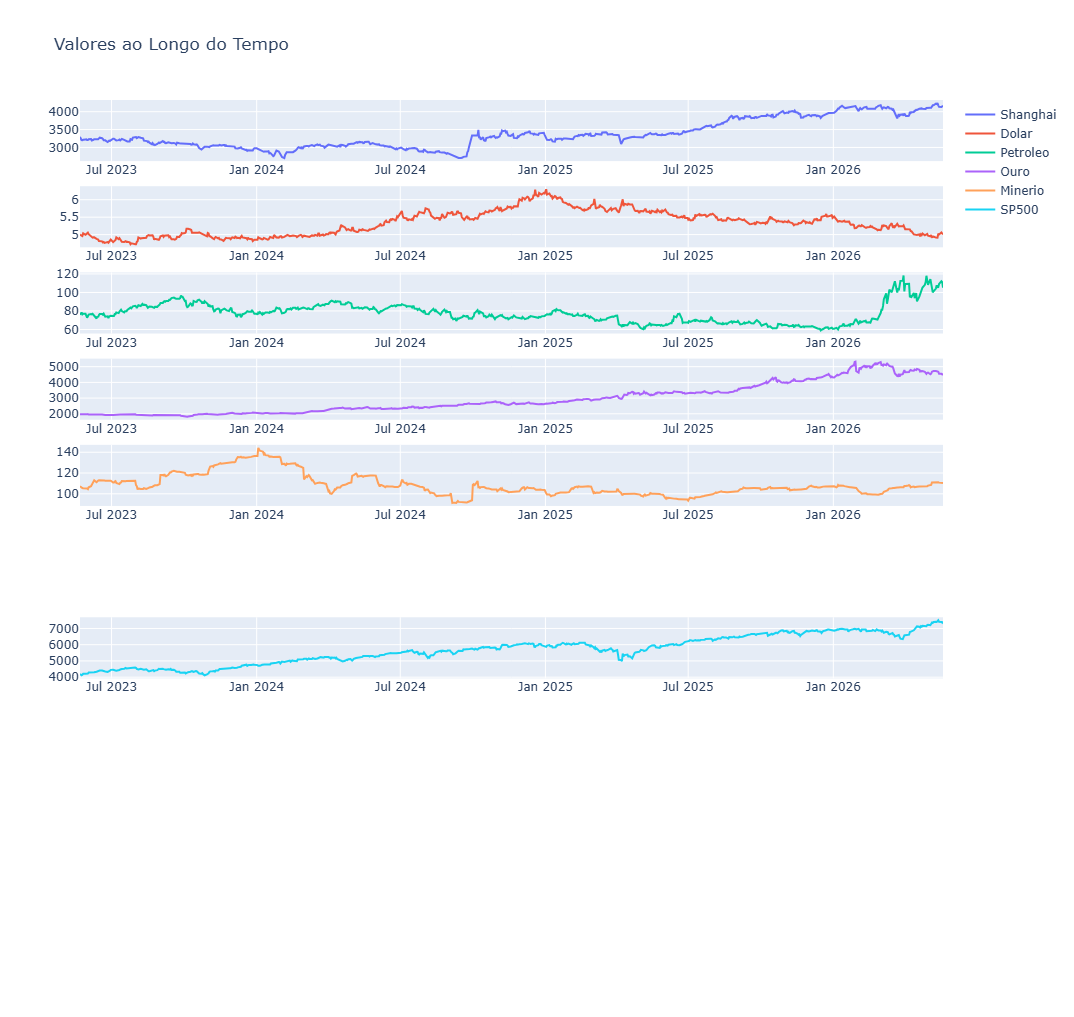

In [11]:
# Plot da cotação de outros commodities
fig = make_subplots(rows = 10, cols = 1)

fig.add_trace(go.Scatter(x = df.reset_index()['Date'], 
                         y = df.reset_index()['Shanghai'],
                         name = 'Shanghai'), row = 1, col = 1
)
fig.add_trace(go.Scatter(x = df.reset_index()['Date'], 
                         y = df.reset_index()['Dolar'],
                         name = 'Dolar'), row = 2, col = 1
)
fig.add_trace(go.Scatter(x = df.reset_index()['Date'], 
                         y = df.reset_index()['Petroleo'],
                         name = 'Petroleo'), row = 3, col = 1
)
fig.add_trace(go.Scatter(x = df.reset_index()['Date'], 
                         y = df.reset_index()['Ouro'],
                         name = 'Ouro'), row = 4, col = 1
)
fig.add_trace(go.Scatter(x = df.reset_index()['Date'], 
                         y = df.reset_index()['Minerio'],
                         name = 'Minerio'), row = 5, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['Date'], 
                         y = df.reset_index()['SP500'],
                         name = 'SP500'), row = 7, col = 1
)

fig.update_layout(height = 1000, width = 1200, title_text = "Valores ao Longo do Tempo")
fig.show()

<Figure size 2500x1000 with 0 Axes>

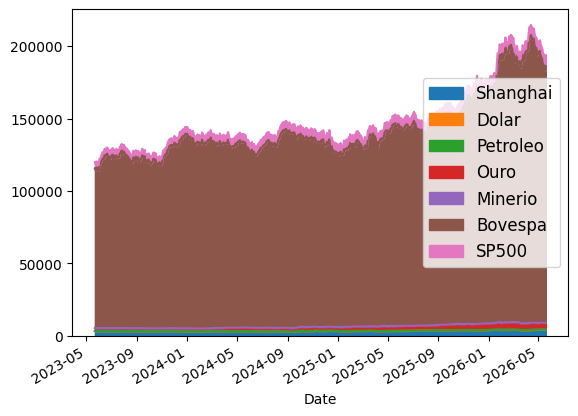

In [12]:
# Plot
plt.figure(figsize = (25,10))
ax = df.plot.area(fontsize = 10);
ax.set_xlabel('Date');
ax.legend(fontsize=12);

In [13]:
# Proporção de dados para treino e teste
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size

In [14]:
# Define o tamanho das amostras
train, test = df.iloc[0:train_size], df.iloc[train_size:len(df)]

In [15]:
print('Tamanho da Amostra de Treino:', len(train))
print('Tamanho da Amostra de Teste:', len(test))

Tamanho da Amostra de Treino: 624
Tamanho da Amostra de Teste: 157


In [16]:
print(train.shape)
train.head()

(624, 7)


Ticker,Shanghai,Dolar,Petroleo,Ouro,Minerio,Bovespa,SP500
Date,,,,,,,
2023-05-22,3296.469971,4.9968,75.989998,1974.800049,107.160004,110213.0,4192.629883
2023-05-23,3246.239990,4.9661,76.839996,1972.400024,106.540001,109929.0,4145.580078
2023-05-24,3204.750000,4.9712,78.360001,1962.800049,105.559998,108800.0,4115.240234
2023-05-25,3201.260010,4.9586,76.260002,1943.099976,105.599998,110054.0,4151.279785
2023-05-26,3212.500000,5.0352,76.949997,1944.099976,105.410004,110906.0,4205.450195


In [17]:
# Variáveis preditoras
variaveis_preditoras = ['SP500', 
                        'Shanghai', 
                        'Dolar', 
                        'Petroleo', 
                        'Ouro',                          
                        'Minerio']                         

In [18]:
# Prepara o padronizador das variáveis preditoras
scaler_preditores = MinMaxScaler()

In [19]:
# Fit nos dados de treino
scaler_preditores = scaler_preditores.fit(train[variaveis_preditoras].to_numpy())

In [20]:
# Transform nos dados de treino
train[variaveis_preditoras] = scaler_preditores.transform(train[variaveis_preditoras].to_numpy())

In [21]:
train.head()

Ticker,Shanghai,Dolar,Petroleo,Ouro,Minerio,Bovespa,SP500
Date,,,,,,,
2023-05-22,0.482458,0.173464,0.433921,0.071047,0.300303,110213.0,0.029331
2023-05-23,0.441679,0.153993,0.457324,0.069969,0.288578,109929.0,0.011499
2023-05-24,0.407997,0.157227,0.499174,0.065658,0.270045,108800.0,0.000000
2023-05-25,0.405163,0.149236,0.441355,0.056811,0.270802,110054.0,0.013659
2023-05-26,0.414288,0.197818,0.460352,0.057260,0.267209,110906.0,0.034190


In [22]:
# Transform nos dados de teste
test[variaveis_preditoras] = scaler_preditores.transform(test[variaveis_preditoras].to_numpy())

In [23]:
test.head()

Ticker,Shanghai,Dolar,Petroleo,Ouro,Minerio,Bovespa,SP500
Date,,,,,,,
2025-10-13,0.963898,0.507198,0.085077,1.029326,0.288389,141783.0,0.962478
2025-10-14,0.944193,0.469842,0.059471,1.042844,0.264183,141683.0,0.958533
2025-10-15,0.982332,0.480878,0.046256,1.059999,0.269856,142604.0,0.968671
2025-10-16,0.985595,0.460455,0.022852,1.106391,0.270045,142200.0,0.952757
2025-10-17,0.923512,0.455074,0.029185,1.065837,0.266074,143399.0,0.965999


In [24]:
# Padronizador da variável alvo
scaler_target = MinMaxScaler()

In [25]:
# Fit nos dados de treino
scaler_target = scaler_target.fit(train[['Bovespa']])

In [26]:
# Transform nos dados de treino
train['Bovespa'] = scaler_target.transform(train[['Bovespa']])

In [27]:
train['Bovespa'].head()

Date
2023-05-22    0.049218
2023-05-23    0.041775
2023-05-24    0.012186
2023-05-25    0.045051
2023-05-26    0.067380
Name: Bovespa, dtype: float64

In [28]:
# Transform nos dados de teste
test['Bovespa'] = scaler_target.transform(test[['Bovespa']])

In [29]:
test['Bovespa'].head()

Date
2025-10-13    0.876589
2025-10-14    0.873968
2025-10-15    0.898105
2025-10-16    0.887517
2025-10-17    0.918940
Name: Bovespa, dtype: float64

In [30]:
# Função para criar o dataset final
def createDataset(X, y, time_steps):
    
    Xs, ys = [], []
    
    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)        
        ys.append(y.iloc[i + time_steps])
        
    return np.array(Xs), np.array(ys)

In [31]:
time_steps = 7

In [32]:
X_train, y_train = createDataset(train, train.Bovespa, time_steps)

In [33]:
X_test, y_test = createDataset(test, test.Bovespa, time_steps)

In [34]:
print(X_train.shape, y_train.shape)

(617, 7, 7) (617,)


In [35]:
print(X_test.shape, y_test.shape)

(150, 7, 7) (150,)


In [36]:
X_train_mlp = X_train[:, :, 0]

In [37]:
X_test_mlp = X_test[:, :, 0]

## Modelo MLP

In [38]:
# Cria o modelo

import tensorflow as tf

modelo_mlp = tf.keras.Sequential()
modelo_mlp.add(tf.keras.layers.Dense(128, input_dim = X_train.shape[1], activation = 'relu'))
modelo_mlp.add(tf.keras.layers.Dense(1))

C:\Users\flavi\anaconda3\envs\SeriesTemporais\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
# Compila o modelo
modelo_mlp.compile(loss = 'mse', optimizer = 'adam')

In [40]:
modelo_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
%%time
modelo_mlp_history = modelo_mlp.fit(X_train_mlp, 
                                    y_train, 
                                    epochs = 100, 
                                    batch_size = 32, 
                                    validation_split = 0.1,
                                    shuffle = False
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0934 - val_loss: 0.0115
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0552 - val_loss: 0.0240
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0539 - val_loss: 0.0039
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0451 - val_loss: 0.0038
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0443 - val_loss: 0.0048
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0411 - val_loss: 0.0068
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0397 - val_loss: 0.0102
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0379 - val_loss: 0.0125
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0368 - val_loss: 0.0158
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0357 - val_loss: 0.0186
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0349 - val_loss: 0.0214
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0

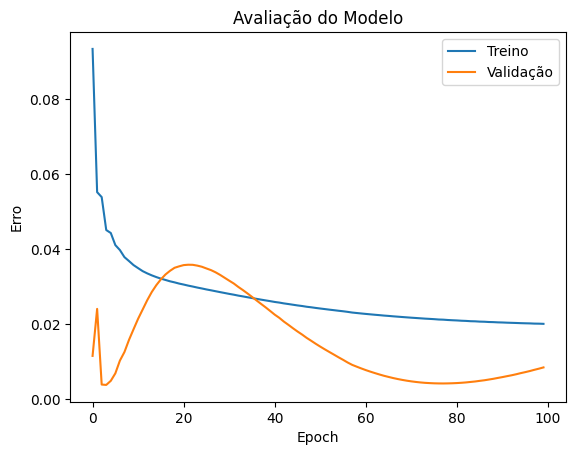

In [42]:
# Plot
plt.plot(modelo_mlp_history.history['loss'])
plt.plot(modelo_mlp_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [43]:
y_pred = modelo_mlp.predict(X_test_mlp)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [44]:
y_pred

array([[0.9896637 ],
       [1.0058593 ],
       [1.0079892 ],
       [1.0178959 ],
       [1.0638417 ],
       [1.0831978 ],
       [1.0879369 ],
       [1.1006254 ],
       [1.0906825 ],
       [1.0840974 ],
       [1.0611134 ],
       [1.060677  ],
       [1.0612918 ],
       [1.073571  ],
       [1.096006  ],
       [1.0972562 ],
       [1.1007018 ],
       [1.1100568 ],
       [1.0948085 ],
       [1.0890486 ],
       [1.0667813 ],
       [1.0514883 ],
       [1.0427201 ],
       [0.9985127 ],
       [0.97557026],
       [0.9614303 ],
       [0.95871246],
       [0.9593248 ],
       [0.964067  ],
       [1.0025368 ],
       [1.0149717 ],
       [1.0039762 ],
       [1.0031612 ],
       [1.0006757 ],
       [1.0080261 ],
       [1.0063856 ],
       [1.0119389 ],
       [1.010627  ],
       [1.005827  ],
       [0.99314797],
       [0.9661751 ],
       [0.96482927],
       [0.9662675 ],
       [0.97991526],
       [0.99295336],
       [1.007697  ],
       [1.0394332 ],
       [1.045

In [45]:
# Invertemos a escala para visualizar o valor real e a previsão
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1,-1))

In [46]:
print(y_train_inv)

[[108335. 110565. 112558. 112696. 114610. 115488. 115488. 117019. 117336.
  116743. 119069. 119221. 118758. 119858. 119622. 120420. 118934. 118977.
  118243. 117523. 116681. 118383. 118087. 119673. 119076. 119549. 117426.
  118898. 117942. 117220. 117666. 119264. 117711. 118219. 117841. 117552.
  118083. 120217. 121342. 122008. 122560. 119990. 120187. 121943. 121248.
  120859. 120586. 119508. 119380. 119090. 118409. 118350. 118065. 116810.
  116171. 115592. 114982. 115409. 114429. 116156. 118135. 117026. 115837.
  117121. 118404. 117535. 115742. 117893. 117777. 117331. 115985. 115985.
  115313. 116883. 117968. 118176. 119392. 118758. 118288. 117846. 118695.
  116145. 116009. 115925. 114193. 114327. 115731. 116565. 115057. 113419.
  113607. 113284. 114170. 115156. 116737. 117051. 117051. 115754. 116534.
  115908. 114060. 114004. 113155. 112785. 113762. 112830. 114777. 113301.
  112532. 113144. 115053. 115053. 118160. 118487. 119268. 119099. 119012.
  120636. 120376. 123328. 123328. 1245

In [47]:
print(y_test_inv)

[[144873.       145721.       146172.       146969.       147429.
  148633.       148780.       149540.       150454.       150704.
  153294.       153339.       154064.       155257.       157749.
  157633.       157162.       157739.       156993.       156522.
  155381.       155381.       154770.       155278.       155910.
  158555.       158292.       159072.       158611.       161092.
  161755.       164456.       157369.       158187.       157981.
  159075.       159189.       160766.       162482.       158578.
  157327.       157923.       158473.       158142.       160456.
  160456.       160456.       160897.       160490.       161125.
  161125.       160539.       161870.       163664.       161975.
  162937.       163370.       163150.       161973.       165146.
  165568.       164800.       164849.       166277.       171817.
  175589.       178859.       178721.       181919.       184691.
  183134.       181364.       182793.       185674.       181708.
  182127. 

In [48]:
print(y_pred_inv)

[[146097.6  146715.56 146796.84 147174.86 148928.   149666.58 149847.4
  150331.56 149952.17 149700.9  148823.9  148807.25 148830.7  149299.25
  150155.3  150203.   150334.48 150691.44 150109.61 149889.83 149040.17
  148456.64 148122.08 146435.25 145559.83 145020.3  144916.6  144939.95
  145120.9  146588.8  147063.28 146643.72 146612.62 146517.78 146798.25
  146735.66 146947.55 146897.5  146714.34 146230.55 145201.34 145149.98
  145204.88 145725.62 146223.12 146785.69 147996.66 148213.22 148680.58
  149040.73 148998.19 149169.64 149098.95 149430.67 150582.61 151697.06
  152625.27 153460.1  154612.9  154877.62 154487.97 154400.39 154099.84
  153664.55 152996.42 153226.53 153466.1  153776.92 154141.25 154190.12
  154484.4  154708.94 154583.47 153259.36 152344.7  152153.25 151714.9
  151614.92 152076.92 153848.62 153883.55 153958.22 153891.23 153728.27
  152776.45 152312.95 152222.95 151953.53 152497.3  152807.33 153475.36
  154082.52 154736.67 155379.67 155403.98 154418.19 153598.62 1533

In [49]:
# Ajusta o shape
y_train_inv = y_train_inv.flatten()
y_train_inv

array([108335., 110565., 112558., 112696., 114610., 115488., 115488.,
       117019., 117336., 116743., 119069., 119221., 118758., 119858.,
       119622., 120420., 118934., 118977., 118243., 117523., 116681.,
       118383., 118087., 119673., 119076., 119549., 117426., 118898.,
       117942., 117220., 117666., 119264., 117711., 118219., 117841.,
       117552., 118083., 120217., 121342., 122008., 122560., 119990.,
       120187., 121943., 121248., 120859., 120586., 119508., 119380.,
       119090., 118409., 118350., 118065., 116810., 116171., 115592.,
       114982., 115409., 114429., 116156., 118135., 117026., 115837.,
       117121., 118404., 117535., 115742., 117893., 117777., 117331.,
       115985., 115985., 115313., 116883., 117968., 118176., 119392.,
       118758., 118288., 117846., 118695., 116145., 116009., 115925.,
       114193., 114327., 115731., 116565., 115057., 113419., 113607.,
       113284., 114170., 115156., 116737., 117051., 117051., 115754.,
       116534., 1159

In [50]:
# Ajusta o shape
y_test_inv = y_test_inv.flatten()
y_test_inv

array([144873.      , 145721.      , 146172.      , 146969.      ,
       147429.      , 148633.      , 148780.      , 149540.      ,
       150454.      , 150704.      , 153294.      , 153339.      ,
       154064.      , 155257.      , 157749.      , 157633.      ,
       157162.      , 157739.      , 156993.      , 156522.      ,
       155381.      , 155381.      , 154770.      , 155278.      ,
       155910.      , 158555.      , 158292.      , 159072.      ,
       158611.      , 161092.      , 161755.      , 164456.      ,
       157369.      , 158187.      , 157981.      , 159075.      ,
       159189.      , 160766.      , 162482.      , 158578.      ,
       157327.      , 157923.      , 158473.      , 158142.      ,
       160456.      , 160456.      , 160456.      , 160897.      ,
       160490.      , 161125.      , 161125.      , 160539.      ,
       161870.      , 163664.      , 161975.      , 162937.      ,
       163370.      , 163150.      , 161973.      , 165146.   

In [51]:
# Ajusta o shape
y_pred_inv = y_pred_inv.flatten()
y_pred_inv

array([146097.6 , 146715.56, 146796.84, 147174.86, 148928.  , 149666.58,
       149847.4 , 150331.56, 149952.17, 149700.9 , 148823.9 , 148807.25,
       148830.7 , 149299.25, 150155.3 , 150203.  , 150334.48, 150691.44,
       150109.61, 149889.83, 149040.17, 148456.64, 148122.08, 146435.25,
       145559.83, 145020.3 , 144916.6 , 144939.95, 145120.9 , 146588.8 ,
       147063.28, 146643.72, 146612.62, 146517.78, 146798.25, 146735.66,
       146947.55, 146897.5 , 146714.34, 146230.55, 145201.34, 145149.98,
       145204.88, 145725.62, 146223.12, 146785.69, 147996.66, 148213.22,
       148680.58, 149040.73, 148998.19, 149169.64, 149098.95, 149430.67,
       150582.61, 151697.06, 152625.27, 153460.1 , 154612.9 , 154877.62,
       154487.97, 154400.39, 154099.84, 153664.55, 152996.42, 153226.53,
       153466.1 , 153776.92, 154141.25, 154190.12, 154484.4 , 154708.94,
       154583.47, 153259.36, 152344.7 , 152153.25, 151714.9 , 151614.92,
       152076.92, 153848.62, 153883.55, 153958.22, 

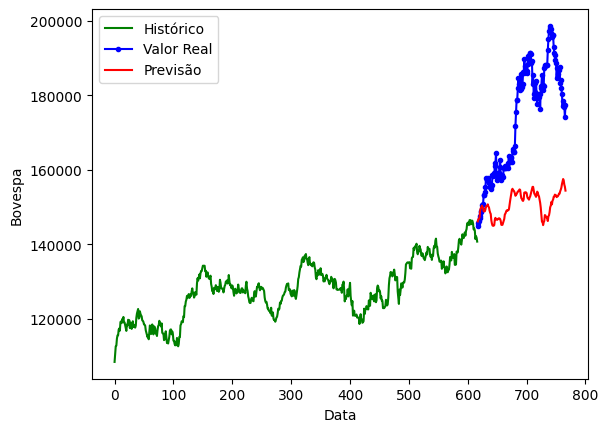

In [52]:
# Plot
plt.plot(np.arange(0, len(y_train)), 
         y_train_inv, 
         color = 'green', 
         label = "Histórico")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_test_inv, 
         color = 'blue', 
         marker = '.', 
         label = "Valor Real")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_pred_inv, 
         color = 'red', 
         label = "Previsão")

plt.ylabel('Bovespa')
plt.xlabel('Data')
plt.legend()
plt.show();

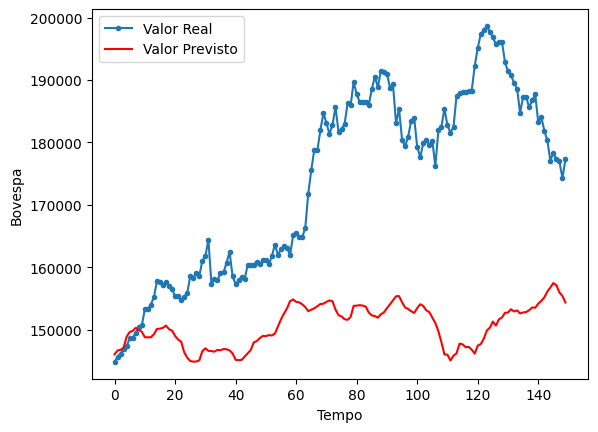

In [53]:
# Plot apenas do valor real x valor previsto
plt.plot(y_test_inv, marker = '.', label = "Valor Real")
plt.plot(y_pred_inv, color = 'red', label = "Valor Previsto")
plt.ylabel('Bovespa')
plt.xlabel('Tempo')
plt.legend()
plt.show();

In [54]:
# Mean Directional Accuracy
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [55]:
# Imprime as métricas

MDA_mlp = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_mlp)

RMSE_mlp = root_mean_squared_error(y_test_inv, y_pred_inv)
print('RMSE:', RMSE_mlp)

MSE_mlp = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_mlp)

RMSE_mlp = root_mean_squared_error(y_test_inv, y_pred_inv)
print('RMSE:', RMSE_mlp)

EVS_mlp = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_mlp)

MDA: 0.4563758389261745
RMSE: 26640.5107197343
MSE: 709716811.408278
RMSE: 26640.5107197343
EVS Score: 0.1568234145825187


In [56]:
# Salva o modelo
def save_model(model):
    json_model = model.to_json()
    open('modelos/modelo_mlp.json', 'w').write(json_model)
    
    # Adicione o ".weights" antes do ".h5"
    model.save_weights('modelos/modelo_mlp.weights.h5', overwrite=True)

In [57]:
save_model(modelo_mlp)

## Modelo LSTM

In [58]:
# Cria o modelo
modelo_lstm = tf.keras.Sequential()
modelo_lstm.add(tf.keras.layers.LSTM(units = 128, input_shape = (X_train.shape[1], X_train.shape[2])))
modelo_lstm.add(tf.keras.layers.Dropout(rate = 0.2))
modelo_lstm.add(tf.keras.layers.Dense(units = 1))

C:\Users\flavi\anaconda3\envs\SeriesTemporais\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
# Compila o modelo
modelo_lstm.compile(loss = 'mse', optimizer = 'adam')

In [60]:
modelo_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,761 (272.50 KB)

 Trainable params: 69,761 (272.50 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
%%time
modelo_lstm_history = modelo_lstm.fit(X_train, 
                                      y_train,
                                      epochs = 100,
                                      batch_size = 32,
                                      validation_split = 0.1,
                                      shuffle = False)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0275 - val_loss: 0.0130
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0212 - val_loss: 0.0035
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0191 - val_loss: 0.0086
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - val_loss: 0.0088
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0167 - val_loss: 0.0039
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0112 - val_loss: 0.0236
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0209 - val_loss: 0.0023
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0083 - val_loss: 0.0024
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078 - val_loss: 0.0055
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073 - val_loss: 0.0044
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 - val_loss: 0.0031
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

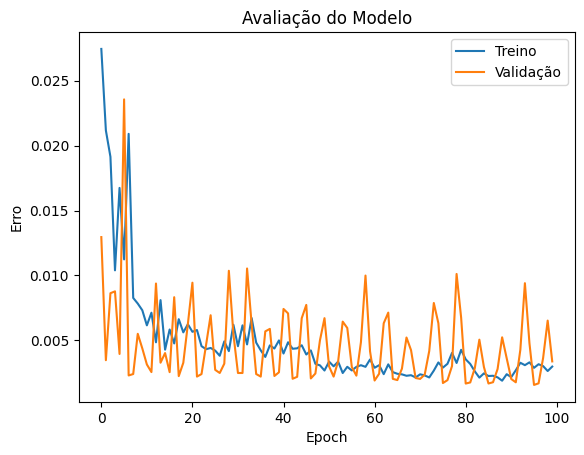

In [62]:
# Plot
plt.plot(modelo_lstm_history.history['loss'])
plt.plot(modelo_lstm_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [63]:
y_pred = modelo_lstm.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [64]:
y_pred

array([[0.92206705],
       [0.9236865 ],
       [0.92979085],
       [0.9370353 ],
       [0.94351244],
       [0.9509852 ],
       [0.9646697 ],
       [0.9717814 ],
       [0.9817653 ],
       [0.99587584],
       [1.0037179 ],
       [1.0323019 ],
       [1.0463207 ],
       [1.0618745 ],
       [1.0856099 ],
       [1.1215796 ],
       [1.1434946 ],
       [1.1431924 ],
       [1.1453102 ],
       [1.137243  ],
       [1.1261113 ],
       [1.1138144 ],
       [1.1057544 ],
       [1.1037498 ],
       [1.1065037 ],
       [1.1186199 ],
       [1.1512766 ],
       [1.1660746 ],
       [1.1802576 ],
       [1.181107  ],
       [1.2033358 ],
       [1.2221789 ],
       [1.2572345 ],
       [1.2041442 ],
       [1.1794959 ],
       [1.1679037 ],
       [1.1741226 ],
       [1.1820772 ],
       [1.204411  ],
       [1.2326664 ],
       [1.2121358 ],
       [1.1828394 ],
       [1.1759151 ],
       [1.1788858 ],
       [1.1771953 ],
       [1.1975422 ],
       [1.211685  ],
       [1.216

In [65]:
# Invertemos a escala para visualizar o valor real e a previsão
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1,-1))

In [66]:
# Ajusta o shape
y_train_inv = y_train_inv.flatten()
y_test_inv = y_test_inv.flatten()
y_pred_inv = y_pred_inv.flatten()

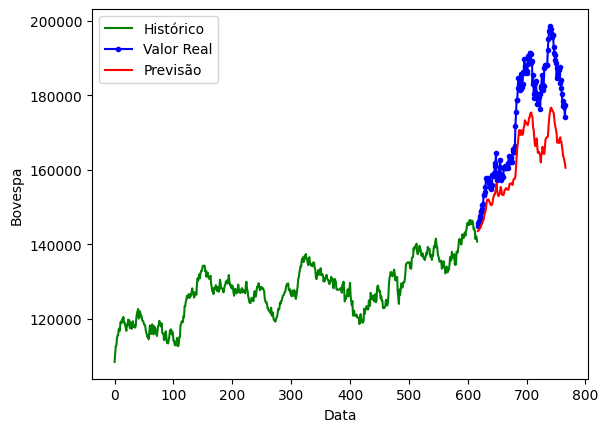

In [67]:
# Plot
plt.plot(np.arange(0, len(y_train)), 
         y_train_inv, 
         color = 'green', 
         label = "Histórico")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_test_inv, 
         color = 'blue', 
         marker = '.', 
         label = "Valor Real")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_pred_inv, 
         color = 'red', 
         label = "Previsão")

plt.ylabel('Bovespa')
plt.xlabel('Data')
plt.legend()
plt.show();

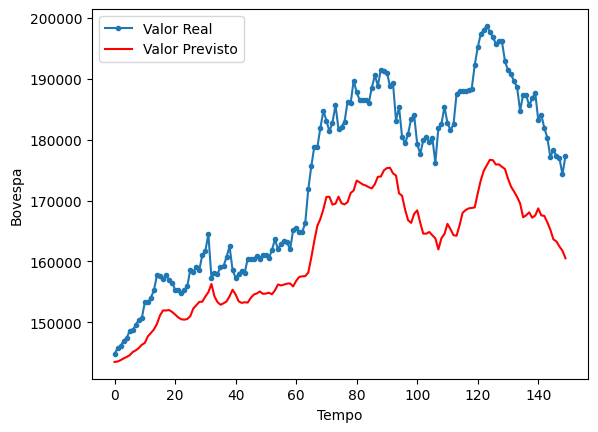

In [68]:
# Plot apenas do valor real x valor previsto
plt.plot(y_test_inv, marker = '.', label = "Valor Real")
plt.plot(y_pred_inv, color = 'red', label = "Valor Previsto")
plt.ylabel('Bovespa')
plt.xlabel('Tempo')
plt.legend()
plt.show();

In [69]:
# Mean Directional Accuracy
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [70]:
# Imprime as métricas

MDA_lstm = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_lstm)

MAE_lstm = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_lstm)

MSE_lstm = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_lstm)

RMSE_lstm = root_mean_squared_error(y_test_inv, y_pred_inv)
print('RMSE:', RMSE_lstm)

EVS_lstm = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_lstm)

MDA: 0.5369127516778524
MAE: 11821.045416666666
MSE: 176351194.3031543
RMSE: 13279.728698401721
EVS Score: 0.8333322308571347


In [71]:
# Salva o modelo
def save_model(model):
    json_model = model.to_json()
    open('modelos/modelo_lstm.json', 'w').write(json_model)
    
    # Adicionando corretamente o ".weights" antes do ".h5" no caminho do arquivo
    model.save_weights('modelos/modelo_lstm.weights.h5', overwrite=True) 

In [72]:
save_model(modelo_lstm)

## Modelo GRU

In [73]:
# Cria o modelo
modelo_gru = tf.keras.Sequential()
modelo_gru.add(tf.keras.layers.GRU(units = 128, input_shape = (X_train.shape[1], X_train.shape[2])))
modelo_gru.add(tf.keras.layers.Dropout(rate = 0.2))
modelo_gru.add(tf.keras.layers.Dense(units = 1))

C:\Users\flavi\anaconda3\envs\SeriesTemporais\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [74]:
# Compila o modelo
modelo_gru.compile(loss = 'mean_squared_error', optimizer = 'adam')

In [75]:
modelo_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        52,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,737 (206.00 KB)

 Trainable params: 52,737 (206.00 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
%%time
modelo_gru_history = modelo_gru.fit(X_train, 
                                    y_train,
                                    epochs = 100,
                                    batch_size = 32,
                                    validation_split = 0.1,
                                    shuffle = False)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0403 - val_loss: 0.0391
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0165 - val_loss: 0.0025
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0135 - val_loss: 0.0025
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0107 - val_loss: 0.0064
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0080 - val_loss: 0.0029
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0070 - val_loss: 0.0095
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097 - val_loss: 0.0082
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0073 - val_loss: 0.0037
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0155 - val_loss: 0.0113
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0072 - val_loss: 0.0149
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0146 - val_loss: 0.0121
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

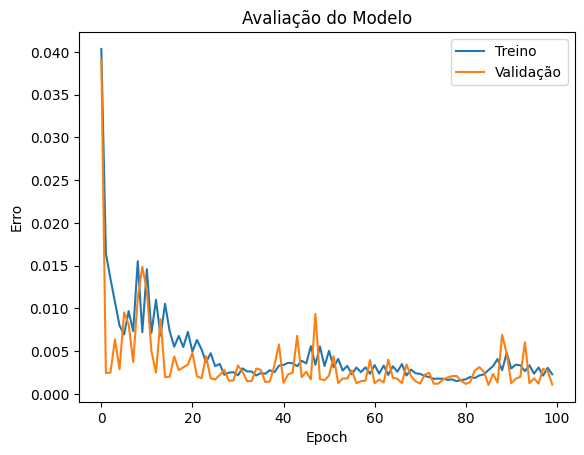

In [77]:
# Plot
plt.plot(modelo_gru_history.history['loss'])
plt.plot(modelo_gru_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [78]:
y_pred = modelo_gru.predict(X_test)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000214821BF100> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [79]:
y_pred

array([[0.9731305 ],
       [0.97024906],
       [0.9988528 ],
       [1.0104806 ],
       [1.0137168 ],
       [1.0204266 ],
       [1.0478938 ],
       [1.054624  ],
       [1.0689993 ],
       [1.0911808 ],
       [1.0912431 ],
       [1.1415696 ],
       [1.1535321 ],
       [1.1666439 ],
       [1.2056999 ],
       [1.2597325 ],
       [1.2713866 ],
       [1.2476578 ],
       [1.2505884 ],
       [1.2365454 ],
       [1.2226706 ],
       [1.2046702 ],
       [1.1950395 ],
       [1.1989174 ],
       [1.2112265 ],
       [1.2295773 ],
       [1.2867184 ],
       [1.2928562 ],
       [1.3035928 ],
       [1.296959  ],
       [1.3393474 ],
       [1.3708619 ],
       [1.4270983 ],
       [1.2905815 ],
       [1.2521417 ],
       [1.2680051 ],
       [1.3001661 ],
       [1.3110636 ],
       [1.3428047 ],
       [1.3822991 ],
       [1.312876  ],
       [1.2596974 ],
       [1.2749512 ],
       [1.2975538 ],
       [1.2966583 ],
       [1.3348656 ],
       [1.3487784 ],
       [1.341

In [80]:
# Invertemos a escala para visualizar o valor real e a previsão
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1,-1))

In [81]:
# Ajusta o shape
y_train_inv = y_train_inv.flatten()
y_test_inv = y_test_inv.flatten()
y_pred_inv = y_pred_inv.flatten()

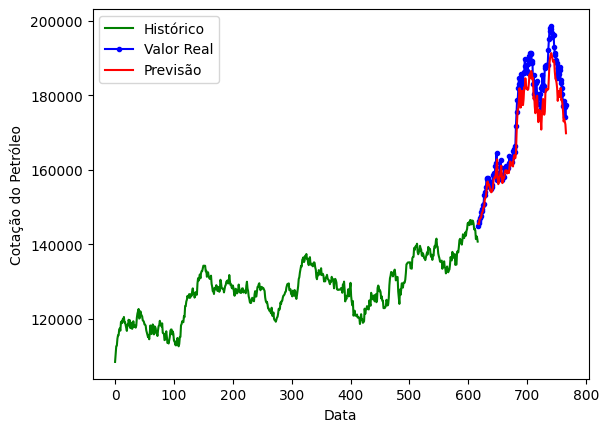

In [82]:
# Plot
plt.plot(np.arange(0, len(y_train)), 
         y_train_inv, 
         color = 'green', 
         label = "Histórico")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_test_inv, 
         color = 'blue', 
         marker = '.', 
         label = "Valor Real")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_pred_inv, 
         color = 'red', 
         label = "Previsão")

plt.ylabel('Cotação do Petróleo')
plt.xlabel('Data')
plt.legend()
plt.show();

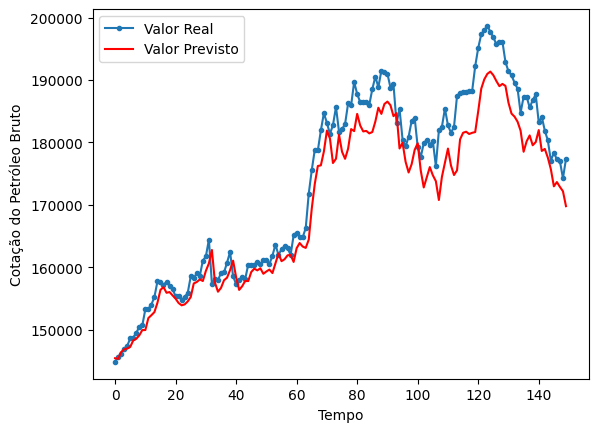

In [83]:
# Plot apenas do valor real x valor previsto
plt.plot(y_test_inv, marker = '.', label = "Valor Real")
plt.plot(y_pred_inv, color = 'red', label = "Valor Previsto")
plt.ylabel('Cotação do Petróleo Bruto')
plt.xlabel('Tempo')
plt.legend()
plt.show();

In [84]:
# Mean Directional Accuracy
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [85]:
# Imprime as métricas

MDA_gru = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_gru)

MAE_gru = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_gru)

MSE_gru = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_gru)

RMSE_gru = root_mean_squared_error(y_test_inv, y_pred_inv)
print('RMSE:', RMSE_gru)

EVS_gru = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_gru)

MDA: 0.5100671140939598
MAE: 3782.1294791666674
MSE: 21807198.852430012
RMSE: 4669.817860733972
EVS Score: 0.9602930621961699


In [86]:
# Salva o modelo
def save_model(model):
    json_model = model.to_json()
    open('modelos/modelo_gru.json', 'w').write(json_model)
    
    # Agora sim, adicionando o ".weights" na string do arquivo!
    model.save_weights('modelos/modelo_gru.weights.h5', overwrite=True) 

In [87]:
save_model(modelo_gru)

## Modelo CNN

In [88]:
# Cria o modelo
modelo_cnn = tf.keras.Sequential()
modelo_cnn.add(tf.keras.layers.Conv1D(filters = 64, 
                                      kernel_size = 2, 
                                      activation = 'relu', 
                                      input_shape = (X_test.shape[1], X_test.shape[2])))
modelo_cnn.add(tf.keras.layers.MaxPooling1D(pool_size = 2))
modelo_cnn.add(tf.keras.layers.Flatten())
modelo_cnn.add(tf.keras.layers.Dense(50, activation = 'relu'))
modelo_cnn.add(tf.keras.layers.Dense(32, activation = 'relu'))
modelo_cnn.add(tf.keras.layers.Dense(1))

C:\Users\flavi\anaconda3\envs\SeriesTemporais\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [89]:
# Compila o modelo
modelo_cnn.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

In [90]:
modelo_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 64)          │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         9,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,275 (47.95 KB)

 Trainable params: 12,275 (47.95 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
%%time
modelo_cnn_history = modelo_cnn.fit(X_train, 
                                    y_train,
                                    epochs = 100,
                                    batch_size = 32,
                                    validation_split = 0.1,
                                    shuffle = False)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0198 - mse: 0.0198 - val_loss: 0.0024 - val_mse: 0.0024
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0116 - mse: 0.0116 - val_loss: 0.0226 - val_mse: 0.0226
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0079 - mse: 0.0079 - val_loss: 0.0126 - val_mse: 0.0126
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0054 - mse: 0.0054 - val_loss: 0.0030 - val_mse: 0.0030
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049 - mse: 0.0049 - val_loss: 0.0063 - val_mse: 0.0063
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 - mse: 0.0076 - val_loss: 0.0245 - val_mse: 0.0245
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0113 - mse: 0.0113 - val_loss: 0.0144 - val_mse: 0.0144
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0089 - mse: 0.0089 - val_loss: 0.0028 - val_mse: 0.0028
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.033

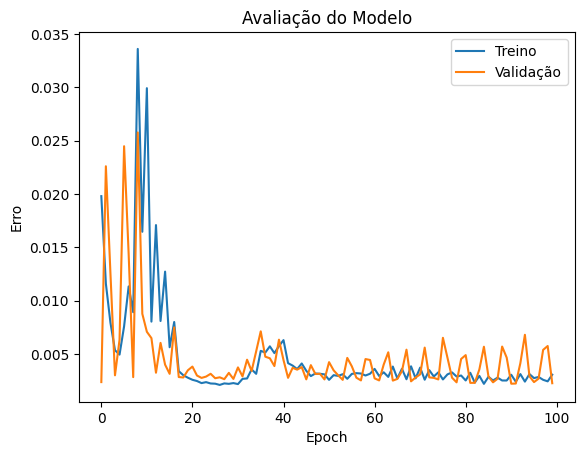

In [92]:
# Plot
plt.plot(modelo_cnn_history.history['loss'])
plt.plot(modelo_cnn_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [93]:
y_pred = modelo_cnn.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [94]:
y_pred

array([[0.99060994],
       [0.99754393],
       [1.001451  ],
       [1.0052109 ],
       [1.0037634 ],
       [1.0081667 ],
       [1.0140241 ],
       [1.0253979 ],
       [1.0306242 ],
       [1.0432141 ],
       [1.0467523 ],
       [1.0709696 ],
       [1.0868585 ],
       [1.0966289 ],
       [1.1288413 ],
       [1.1612499 ],
       [1.1933168 ],
       [1.1974118 ],
       [1.1967506 ],
       [1.1965902 ],
       [1.1903983 ],
       [1.1726679 ],
       [1.1610179 ],
       [1.1549021 ],
       [1.1587796 ],
       [1.168733  ],
       [1.1986263 ],
       [1.2203995 ],
       [1.2365961 ],
       [1.2453214 ],
       [1.2542509 ],
       [1.2800978 ],
       [1.3110963 ],
       [1.3148557 ],
       [1.2914172 ],
       [1.2527027 ],
       [1.2452492 ],
       [1.2510067 ],
       [1.2644532 ],
       [1.2927994 ],
       [1.2970382 ],
       [1.292425  ],
       [1.2575666 ],
       [1.2551509 ],
       [1.251295  ],
       [1.2637323 ],
       [1.2772653 ],
       [1.287

In [95]:
# Invertemos a escala para visualizar o valor real e a previsão
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1,-1))

In [96]:
# Ajusta o shape
y_train_inv = y_train_inv.flatten()
y_test_inv = y_test_inv.flatten()
y_pred_inv = y_pred_inv.flatten()

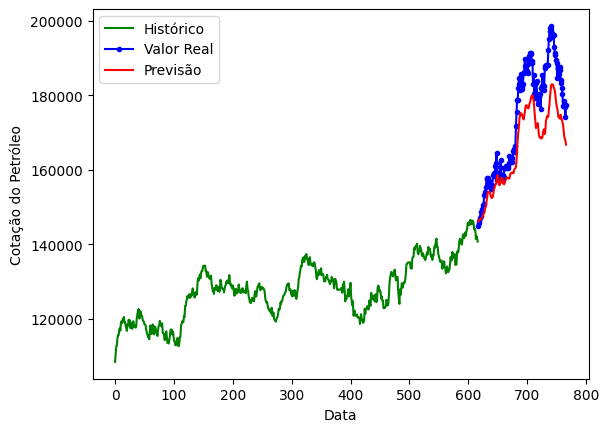

In [97]:
# Plot
plt.plot(np.arange(0, len(y_train)), 
         y_train_inv, 
         color = 'green', 
         label = "Histórico")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_test_inv, 
         color = 'blue', 
         marker = '.', 
         label = "Valor Real")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_pred_inv, 
         color = 'red', 
         label = "Previsão")

plt.ylabel('Cotação do Petróleo')
plt.xlabel('Data')
plt.legend()
plt.show();

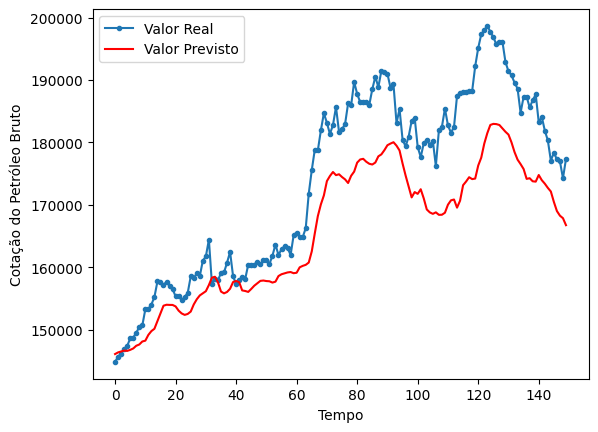

In [98]:
# Plot apenas do valor real x valor previsto
plt.plot(y_test_inv, marker = '.', label = "Valor Real")
plt.plot(y_pred_inv, color = 'red', label = "Valor Previsto")
plt.ylabel('Cotação do Petróleo Bruto')
plt.xlabel('Tempo')
plt.legend()
plt.show();

In [99]:
# Mean Directional Accuracy
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [100]:
# Imprime as métricas

MDA_cnn = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_cnn)

MAE_cnn = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_cnn)

MSE_cnn = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_cnn)

RMSE_cnn = root_mean_squared_error(y_test_inv, y_pred_inv)
print('RMSE:', RMSE_cnn)

EVS_cnn = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_cnn)

MDA: 0.5302013422818792
MAE: 7829.459583333333
MSE: 84479433.37882487
RMSE: 9191.269410632292
EVS Score: 0.8905824017167858


In [101]:
# Salva o modelo
def save_model(model):
    json_model = model.to_json()
    open('modelos/modelo_lstm.json', 'w').write(json_model)
    
    # Adicionando corretamente o ".weights" antes do ".h5" no caminho do arquivo
    model.save_weights('modelos/modelo_cnn.weights.h5', overwrite=True) 

In [102]:
save_model(modelo_cnn)

In [103]:
import joblib
import os
from sklearn.preprocessing import MinMaxScaler

# Cria a pasta 'modelos' caso ela ainda não exista
if not os.path.exists('modelos'):
    os.makedirs('modelos')

# =====================================================================
# 1. CRIANDO E TREINANDO OS SCALERS (Para garantir que existem na memória)
# =====================================================================
colunas_features = df.columns
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# O .fit() é o que faz o scaler aprender os mínimos e máximos da sua base 'df'
scaler_X.fit(df[colunas_features])
scaler_y.fit(df['Bovespa'].values.reshape(-1, 1))

# =====================================================================
# 2. SALVANDO OS SCALERS NO SEU COMPUTADOR
# =====================================================================
joblib.dump(scaler_X, 'modelos/scaler_X.pkl')
joblib.dump(scaler_y, 'modelos/scaler_y.pkl')

print("✅ Scalers criados, treinados e salvos com sucesso na pasta 'modelos'!")

✅ Scalers criados, treinados e salvos com sucesso na pasta 'modelos'!
